In [ ]:
import torch

print("CUDA available:", torch.cuda.is_available())
print("CUDA version:", torch.version.cuda)
print("Device count:", torch.cuda.device_count())

if torch.cuda.is_available():
    print("GPU name:", torch.cuda.get_device_name(0))


CUDA available: True
CUDA version: 12.1
Device count: 1
GPU name: NVIDIA GeForce RTX 4060 Laptop GPU


In [2]:
import pandas as pd
import os
import sys
from pathlib import Path
import torch

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
# Display all columns
pd.set_option('display.max_columns', None)

# Display all rows
pd.set_option('display.max_rows', None)

# Set the width to show all content in each cell
pd.set_option('display.width', None)

# Set the max string length to display
pd.set_option('display.max_colwidth', None)


In [5]:
sys.path.append('C:/Users/rishe/Dissertation')

In [8]:
EXP_ID = f'exp_3_window_experiment'
DATA_PATH = f'C:/Users/rishe/Dissertation/data/processed_rain.parquet'

In [9]:
df_long = pd.read_parquet(DATA_PATH)

In [10]:
df_long.shape

(4741665, 11)

In [11]:
df_long['station_id'].nunique()

293

### data pre-processing

In [12]:
df_long.head()

,station_id,date,year,month,day,day_of_year,rainfall,lat,lon,district,station_type
0,AKRIGANJ,1901-01-01,1901,1,1,1,4.1,NaN,NaN,MURSHIDABAD,None
1,AKRIGANJ,1901-01-02,1901,1,2,2,3.3,NaN,NaN,MURSHIDABAD,None
2,AKRIGANJ,1901-01-03,1901,1,3,3,0.3,NaN,NaN,MURSHIDABAD,None
3,AKRIGANJ,1901-01-04,1901,1,4,4,0.3,NaN,NaN,MURSHIDABAD,None
4,AKRIGANJ,1901-01-05,1901,1,5,5,0.0,NaN,NaN,MURSHIDABAD,None


In [13]:
df_long.isna().sum()

station_id            0
date                  0
year                  0
month                 0
day                   0
day_of_year           0
rainfall         782517
lat              116514
lon              116514
district              0
station_type    2977122
dtype: int64

In [14]:
df_long = df_long.dropna(subset=['rainfall'])

In [15]:
station_summary = df_long.groupby('station_id').agg(
    data_available_in_days=('rainfall', 'count'),
    rainy_days=('rainfall', lambda x: (x > 0).sum())
).reset_index()

In [17]:
station_summary.head()

,station_id,data_available_in_days,rainy_days
0,AKRIGANJ,15713,3599
1,ALGARAH,13575,5625
2,ALIPUR,43752,14650
3,ALIPURDUAR,34602,11853
4,ALIPURDUAR(CWC),4937,1847


In [18]:
station_summary['rainy_days'].sum()

1121149

### Data splits

In [19]:
from utils.data_utils.data_helper_utils import temporal_split

In [20]:
df_train, df_val, df_test = temporal_split(df_long)

### Dataset preparation

In [21]:
from utils.data_utils.dataset_files.dataset_with_meta_features import RainfallWindowDataset

In [28]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [26]:
# Window length experiment configuration
WINDOW_LENGTHS = [7, 14, 60]
HORIZON = 1
BATCH_SIZE = 64
EPOCHS = 10
HIDDEN_DIM = 128

# Dictionary to store results for each window length
window_experiment_results = {}
trained_models = {}

print(f"Configured window lengths: {WINDOW_LENGTHS}")
print(f"Horizon: {HORIZON}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS}")


Configured window lengths: [7, 14, 60]
Horizon: 1
Batch size: 64
Epochs: 10


In [24]:
device

device(type='cuda')

In [27]:
# Loop through each window length and create datasets
datasets_by_window = {}

for window_length in WINDOW_LENGTHS:
    print(f"\n{'='*60}")
    print(f"Creating datasets for window length: {window_length}")
    print(f"{'='*60}")
    
    train_ds_window = RainfallWindowDataset(
        df_train,
        window_length=window_length,
        horizon=HORIZON,
        min_days_per_station=window_length + HORIZON
    )
    
    val_ds_window = RainfallWindowDataset(
        df_val,
        window_length=window_length,
        horizon=HORIZON,
        min_days_per_station=window_length + HORIZON
    )
    
    test_ds_window = RainfallWindowDataset(
        df_test,
        window_length=window_length,
        horizon=HORIZON,
        min_days_per_station=window_length + HORIZON
    )
    
    datasets_by_window[window_length] = {
        'train': train_ds_window,
        'val': val_ds_window,
        'test': test_ds_window
    }
    
    print(f"Train samples: {len(train_ds_window)}")
    print(f"Val samples: {len(val_ds_window)}")
    print(f"Test samples: {len(test_ds_window)}")



Creating datasets for window length: 7
Train samples: 2769218
Val samples: 591811
Test samples: 591966

Creating datasets for window length: 14
Train samples: 2767167
Val samples: 589798
Test samples: 589947

Creating datasets for window length: 60
Train samples: 2753819
Val samples: 576844
Test samples: 576992


### training

In [29]:
import torch

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Compiled with CUDA:", torch.version.cuda)
print("GPU count:", torch.cuda.device_count())


Torch version: 2.5.1
CUDA available: True
Compiled with CUDA: 12.1
GPU count: 1


In [1]:
DATA_PATH

NameError: name 'DATA_PATH' is not defined

In [31]:
model_save_path = f"C:/Users/rishe/Dissertation/experiments/saved_models/{EXP_ID}"
log_save_path = f"C:/Users/rishe/Dissertation/experiments/logs/{EXP_ID}"
log_save_path

'C:/Users/rishe/Dissertation/experiments/logs/exp_3_window_experiment'

In [32]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [33]:
from models.baseline_lstm import *

In [69]:
model = RainfallLSTM(
    input_dim=train_ds.X.shape[-1],
    hidden_dim=128
).to(device)


In [ ]:
# Train models for each window length
from datetime import datetime

for window_length in WINDOW_LENGTHS:
    print(f"\n{'='*60}")
    print(f"Training model for window length: {window_length}")
    print(f"Start time: {datetime.now()}")
    print(f"{'='*60}")
    
    # Get datasets for this window length
    train_ds = datasets_by_window[window_length]['train']
    val_ds = datasets_by_window[window_length]['val']
    test_ds = datasets_by_window[window_length]['test']
    
    # Create model with appropriate input dimension for this window length
    model_window = RainfallLSTM(
        input_dim=train_ds.X.shape[-1],
        hidden_dim=HIDDEN_DIM
    ).to(device)
    
    # Set up paths for this window length
    exp_name = f'exp_3_window_{window_length}_days'
    model_save_path_window = f"C:/Users/rishe/Dissertation/experiments/saved_models/{exp_name}"
    log_save_path_window = f"C:/Users/rishe/Dissertation/experiments/logs/{exp_name}"
    
    # Train the model
    trained_model = train_model(
        train_ds=train_ds,
        val_ds=val_ds,
        model=model_window,
        device=device,
        batch_size=BATCH_SIZE,
        epochs=EPOCHS,
        save_dir=model_save_path_window,
        log_dir=log_save_path_window,
        experiment_name=exp_name
    )
    
    # Store the trained model
    trained_models[window_length] = trained_model
    
    # Evaluate on test set
    test_metrics = evaluate_on_test(
        test_ds,
        trained_model,
        device
    )
    
    window_experiment_results[window_length] = {
        'model': trained_model,
        'model_path': model_save_path_window,
        'log_path': log_save_path_window,
        'test_metrics': test_metrics
    }
    
    print(f"End time: {datetime.now()}")
    print(f"Test Metrics: {test_metrics}")

print(f"\n{'='*60}")
print("All window length experiments completed!")
print(f"{'='*60}")



Training model for window length: 7
Start time: 2026-02-08 18:45:24.762551
2026-02-08 18:45:24 | INFO | Starting training
2026-02-08 18:45:24 | INFO | Device: cuda


Epochs:  10%|█         | 1/10 [02:18<20:42, 138.10s/it, train=237.4072, val=249.5084]

2026-02-08 18:47:44 | INFO | Epoch 001 | Train Loss: 237.407220 | Val Loss: 249.508407
2026-02-08 18:47:44 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_3_window_7_days\epoch_1.pt


Epochs:  20%|██        | 2/10 [04:27<17:45, 133.15s/it, train=236.2912, val=248.8080]

2026-02-08 18:49:53 | INFO | Epoch 002 | Train Loss: 236.291191 | Val Loss: 248.807958
2026-02-08 18:49:53 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_3_window_7_days\epoch_2.pt


...

2026-02-08 19:15:49 | INFO | Epoch 003 | Train Loss: 234.901666 | Val Loss: 247.704747
2026-02-08 19:15:49 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_3_window_14_days\epoch_3.pt


Epochs:  40%|████      | 4/10 [10:03<14:59, 150.00s/it, train=234.7737, val=247.7905]

2026-02-08 19:18:15 | INFO | Epoch 004 | Train Loss: 234.773663 | Val Loss: 247.790493
2026-02-08 19:18:15 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_3_window_14_days\epoch_4.pt


Epochs:  50%|█████     | 5/10 [12:30<12:25, 149.12s/it, train=234.6906, val=247.6728]

2026-02-08 19:20:43 | INFO | Epoch 005 | Train Loss: 234.690606 | Val Loss: 247.672828
2026-02-08 19:20:43 | INFO | Checkpoint saved: C:/Users/rishe/Dissertation/experiments/saved_models/exp_3_window_14_days\epoch_5.pt


### Evaluation


In [ ]:
# Comprehensive evaluation for each window length
evaluation_results = {}

for window_length in WINDOW_LENGTHS:
    print(f"\n{'='*60}")
    print(f"Evaluating window length: {window_length}")
    print(f"{'='*60}")
    
    # Get the trained model
    trained_model = window_experiment_results[window_length]['model']
    test_ds = datasets_by_window[window_length]['test']
    
    # Load best checkpoint (epoch 9)
    model_path = window_experiment_results[window_length]['model_path']
    ckpt_path = f"{model_path}/epoch_9.pt"
    
    try:
        checkpoint = torch.load(ckpt_path, map_location=device)
        trained_model.load_state_dict(checkpoint["model_state_dict"])
        trained_model.to(device)
        trained_model.eval()
        
        # Collect predictions
        df_eval_window = collect_test_predictions(
            test_ds=test_ds,
            model=trained_model,
            device=device
        )
        
        # Calculate metrics
        df_eval_window["error"] = df_eval_window["y"] - df_eval_window["yhat"]
        
        overall_metrics_window = {
            "RMSE": rmse(df_eval_window.y.values, df_eval_window.yhat.values),
            "MAE": mae(df_eval_window.y.values, df_eval_window.yhat.values),
            "Bias": bias(df_eval_window.y.values, df_eval_window.yhat.values),
            "NRMSE": nrmse(df_eval_window.y.values, df_eval_window.yhat.values),
        }
        
        evaluation_results[window_length] = {
            'df_eval': df_eval_window,
            'metrics': overall_metrics_window
        }
        
        print(f"Overall Metrics for Window Length {window_length}:")
        print(pd.DataFrame(overall_metrics_window, index=["Overall"]))
        
    except Exception as e:
        print(f"Error evaluating window length {window_length}: {e}")
        continue


In [ ]:
# Compare results across all window lengths
print("\n" + "="*60)
print("SUMMARY: Window Length Comparison")
print("="*60)

comparison_data = []
for window_length in WINDOW_LENGTHS:
    if window_length in evaluation_results:
        metrics = evaluation_results[window_length]['metrics']
        comparison_data.append({
            'Window Length': window_length,
            'RMSE': round(metrics['RMSE'], 4),
            'MAE': round(metrics['MAE'], 4),
            'Bias': round(metrics['Bias'], 4),
            'NRMSE': round(metrics['NRMSE'], 4),
        })

df_comparison = pd.DataFrame(comparison_data)
print("\n")
print(df_comparison.to_string(index=False))

# Identify best performing window length
if comparison_data:
    best_window = min(comparison_data, key=lambda x: x['RMSE'])
    print(f"\n\nBest performing window length (by RMSE): {best_window['Window Length']} days")
    print(f"RMSE: {best_window['RMSE']}")


In [ ]:
# Visualize window length comparison
import matplotlib.pyplot as plt

if comparison_data:
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle('Window Length Experiment Results Comparison', fontsize=14, fontweight='bold')
    
    window_lengths_list = [d['Window Length'] for d in comparison_data]
    
    # RMSE
    rmse_values = [d['RMSE'] for d in comparison_data]
    axes[0, 0].plot(window_lengths_list, rmse_values, marker='o', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Window Length (days)')
    axes[0, 0].set_ylabel('RMSE (mm)')
    axes[0, 0].set_title('RMSE by Window Length')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_xticks(window_lengths_list)
    
    # MAE
    mae_values = [d['MAE'] for d in comparison_data]
    axes[0, 1].plot(window_lengths_list, mae_values, marker='o', linewidth=2, markersize=8, color='orange')
    axes[0, 1].set_xlabel('Window Length (days)')
    axes[0, 1].set_ylabel('MAE (mm)')
    axes[0, 1].set_title('MAE by Window Length')
    axes[0, 1].grid(True, alpha=0.3)
    axes[0, 1].set_xticks(window_lengths_list)
    
    # Bias
    bias_values = [d['Bias'] for d in comparison_data]
    axes[1, 0].plot(window_lengths_list, bias_values, marker='o', linewidth=2, markersize=8, color='green')
    axes[1, 0].set_xlabel('Window Length (days)')
    axes[1, 0].set_ylabel('Bias (mm)')
    axes[1, 0].set_title('Bias by Window Length')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].set_xticks(window_lengths_list)
    
    # NRMSE
    nrmse_values = [d['NRMSE'] for d in comparison_data]
    axes[1, 1].plot(window_lengths_list, nrmse_values, marker='o', linewidth=2, markersize=8, color='red')
    axes[1, 1].set_xlabel('Window Length (days)')
    axes[1, 1].set_ylabel('NRMSE')
    axes[1, 1].set_title('NRMSE by Window Length')
    axes[1, 1].grid(True, alpha=0.3)
    axes[1, 1].set_xticks(window_lengths_list)
    
    plt.tight_layout()
    plt.show()


In [ ]:
# Seasonal analysis for each window length
monsoon_months = [6, 7, 8, 9]
non_monsoon_months = [1, 2, 3, 4, 5, 10, 11, 12]

print("\n" + "="*60)
print("SEASONAL ANALYSIS BY WINDOW LENGTH")
print("="*60)

seasonal_comparison = {}

for window_length in WINDOW_LENGTHS:
    if window_length in evaluation_results:
        df_eval_window = evaluation_results[window_length]['df_eval']
        
        # Seasonal subsets
        df_monsoon = seasonal_subset(df_eval_window, monsoon_months)
        df_non_monsoon = seasonal_subset(df_eval_window, non_monsoon_months)
        
        seasonal_metrics_window = pd.DataFrame({
            "Monsoon": {
                "RMSE": rmse(df_monsoon.y, df_monsoon.yhat),
                "MAE": mae(df_monsoon.y, df_monsoon.yhat),
                "Bias": bias(df_monsoon.y, df_monsoon.yhat),
            },
            "Non-Monsoon": {
                "RMSE": rmse(df_non_monsoon.y, df_non_monsoon.yhat),
                "MAE": mae(df_non_monsoon.y, df_non_monsoon.yhat),
                "Bias": bias(df_non_monsoon.y, df_non_monsoon.yhat),
            }
        }).T
        
        seasonal_comparison[window_length] = seasonal_metrics_window
        
        print(f"\nWindow Length: {window_length} days")
        print(seasonal_metrics_window.round(4))


### Baseline evaluation

In [75]:
from utils.metric_utils.metrics import *

In [77]:
ckpt_path = f"{model_save_path}/epoch_9.pt"  

In [79]:
ckpt_path

'C:/Users/rishe/Dissertation/experiments/saved_models/exp_2_baseline_wet_days/epoch_9.pt'

In [81]:
checkpoint = torch.load(ckpt_path, map_location=device)
model.load_state_dict(checkpoint["model_state_dict"])
model.to(device)
model.eval()


C:\Users\rishe\AppData\Local\Temp\ipykernel_15188\3928164772.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(ckpt_path, map_location=device)


RainfallLSTM(
  (lstm): LSTM(7, 128, batch_first=True)
  (head): Linear(in_features=128, out_features=1, bias=True)
)

In [83]:
df_eval = collect_test_predictions(
    test_ds=test_ds,
    model=model,
    device=device
)

df_eval.head()


,y,yhat,month,station_id,lat,lon
0,3.3,13.015110,7,AKRIGANJ,NaN,NaN
1,13.5,12.872677,8,AKRIGANJ,NaN,NaN
2,3.3,14.955650,8,AKRIGANJ,NaN,NaN
3,14.0,12.883033,8,AKRIGANJ,NaN,NaN
4,15.0,14.975442,8,AKRIGANJ,NaN,NaN


#### Overall evaluation metrics

In [86]:
overall_metrics = {
    "RMSE": rmse(df_eval.y.values, df_eval.yhat.values),
    "MAE": mae(df_eval.y.values, df_eval.yhat.values),
    "Bias": bias(df_eval.y.values, df_eval.yhat.values),
    "NRMSE": nrmse(df_eval.y.values, df_eval.yhat.values),
}

pd.DataFrame(overall_metrics, index=["Overall"])


,RMSE,MAE,Bias,NRMSE
Overall,26.985201,16.544153,-0.636365,1.353191


In [88]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# prediction error
df_eval["error"] = df_eval["y"] - df_eval["yhat"]

# masks
rainy_mask = df_eval["y"] > 0
non_rainy_mask = df_eval["y"] == 0

monsoon_months = [6, 7, 8, 9]
non_monsoon_months = [1, 2, 3, 4, 5, 10, 11, 12]

monsoon_mask = df_eval["month"].isin(monsoon_months)
non_monsoon_mask = df_eval["month"].isin(non_monsoon_months)


In [90]:
non_rainy_mask.sum()/df_eval.shape[0]

0.0

In [92]:
(df_eval['error']).describe(percentiles = [0.1,.2,.25,.3,.4,.5,.6,.7,.75,.8,.9,.95,.96,.97,.98,.99])

count    160052.000000
mean          0.636365
std          26.977779
min         -58.347073
10%         -18.230273
20%         -14.192009
25%         -12.897211
30%         -11.772685
40%          -9.493309
50%          -6.787091
60%          -3.331686
70%           1.900199
75%           5.608690
80%          10.404037
90%          27.642384
95%          48.713873
96%          56.070647
97%          65.658412
98%          80.722445
99%         109.201853
max         601.604858
Name: error, dtype: float64

#### Seasonal evaluation

In [94]:
monsoon_months = [6, 7, 8, 9]
non_monsoon_months = [1, 2, 3, 4, 5, 10, 11, 12]

df_monsoon = seasonal_subset(df_eval, monsoon_months)
df_non_monsoon = seasonal_subset(df_eval, non_monsoon_months)

seasonal_metrics = pd.DataFrame({
    "Monsoon": {
        "RMSE": rmse(df_monsoon.y, df_monsoon.yhat),
        "MAE": mae(df_monsoon.y, df_monsoon.yhat),
        "Bias": bias(df_monsoon.y, df_monsoon.yhat),
    },
    "Non-Monsoon": {
        "RMSE": rmse(df_non_monsoon.y, df_non_monsoon.yhat),
        "MAE": mae(df_non_monsoon.y, df_non_monsoon.yhat),
        "Bias": bias(df_non_monsoon.y, df_non_monsoon.yhat),
    }
}).T

seasonal_metrics


,RMSE,MAE,Bias
Monsoon,28.684891,17.821899,-0.864164
Non-Monsoon,21.638165,13.033314,-0.010447


#### Per station performance table

In [97]:
df_station_metrics = stationwise_metrics(df_eval)

df_station_metrics.head()


C:\Users/rishe/Dissertation\utils\metric_utils\metrics.py:75: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


,station_id,RMSE,MAE,Bias,Count
0,AKRIGANJ,29.325104,19.416300,-2.852286,510.0
1,ALGARAH,23.235346,14.485863,0.108170,814.0
2,ALIPUR,22.258232,14.627949,0.264661,2168.0
3,ALIPURDUAR,43.789852,26.172937,-5.905062,1748.0
4,ALIPURDUAR(CWC),61.433224,33.832439,-13.198258,248.0


In [99]:
df_station_metrics.describe()

,RMSE,MAE,Bias,Count
count,262.000000,262.000000,262.000000,262.000000
mean,24.286965,15.925197,-0.217640,610.885496
std,8.599192,4.712921,3.063733,465.506203
min,7.867133,7.867133,-24.395838,1.000000
25%,18.888585,13.151492,-1.289907,285.750000
50%,22.156902,14.456282,0.291660,494.500000
75%,27.556478,17.275227,1.116048,804.250000
max,84.428230,46.878811,13.424536,2421.000000


#### Month-wise RMSE

In [101]:
df_long.month.unique()

array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12], dtype=int64)

In [103]:
df_eval.tail()

,y,yhat,month,station_id,lat,lon,error
160047,3.6,18.060543,6,VISHNUPUR,23.08,87.32,-14.460543
160048,16.4,13.930995,6,VISHNUPUR,23.08,87.32,2.469005
160049,2.4,15.881577,6,VISHNUPUR,23.08,87.32,-13.481577
160050,5.0,13.018985,6,VISHNUPUR,23.08,87.32,-8.018985
160051,3.8,12.596073,6,VISHNUPUR,23.08,87.32,-8.796073


C:\Users\rishe\AppData\Local\Temp\ipykernel_15188\803231696.py:8: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: rmse(g.y.values, g.yhat.values))


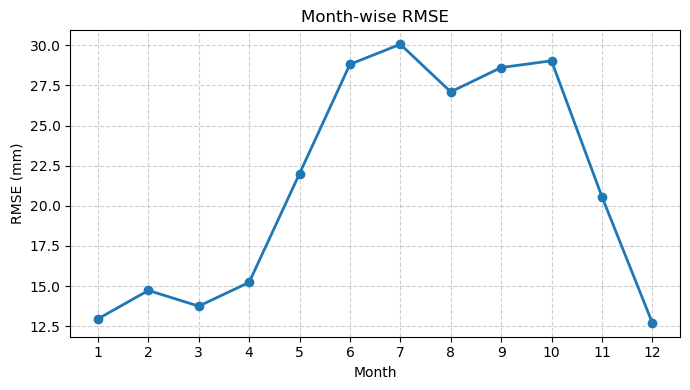

In [105]:
import numpy as np
import matplotlib.pyplot as plt

# compute month-wise RMSE
month_rmse = (
    df_eval
    .groupby("month")
    .apply(lambda g: rmse(g.y.values, g.yhat.values))
    .sort_index()
)

# plot
plt.figure(figsize=(7, 4))
plt.plot(
    month_rmse.index,
    month_rmse.values,
    marker="o",
    linewidth=2
)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("RMSE (mm)")
plt.title("Month-wise RMSE")
plt.grid(True, which="both", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


In [107]:
# baseline 1: predict zero
yhat_zero = np.zeros_like(df_eval.y)

# baseline 2: predict mean rainfall
yhat_mean = np.full_like(df_eval.y, df_eval.y.mean())

baseline_table = pd.DataFrame({
    "Model": {
        "RMSE": rmse(df_eval.y, df_eval.yhat),
        "MAE": mae(df_eval.y, df_eval.yhat),
    },
    "Zero Predictor": {
        "RMSE": rmse(df_eval.y, yhat_zero),
        "MAE": mae(df_eval.y, yhat_zero),
    },
    "Mean Predictor": {
        "RMSE": rmse(df_eval.y, yhat_mean),
        "MAE": mae(df_eval.y, yhat_mean),
    },
}).T

baseline_table


,RMSE,MAE
Model,26.985201,16.544153
Zero Predictor,34.799793,19.941904
Mean Predictor,28.519224,17.939289


#### Error distribution

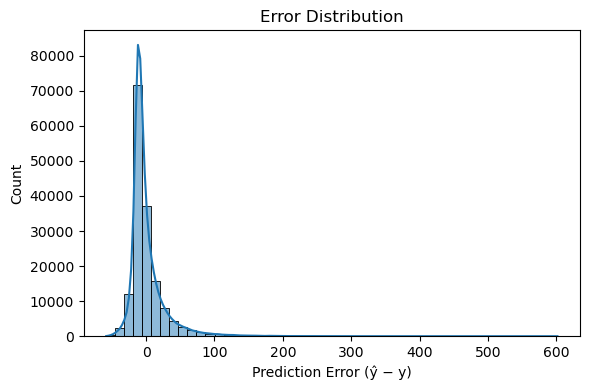

In [109]:
errors = df_eval.error

plt.figure(figsize=(6, 4))
sns.histplot(errors, bins=50, kde=True)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution")
plt.tight_layout()
plt.show()


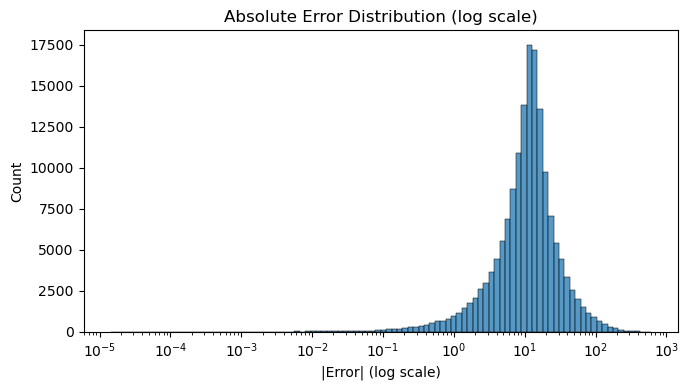

In [111]:
plt.figure(figsize=(7, 4))

sns.histplot(
    np.abs(df_eval["error"]) + 1e-6,
    bins=100,
    log_scale=True
)

plt.xlabel("|Error| (log scale)")
plt.title("Absolute Error Distribution (log scale)")
plt.tight_layout()
plt.show()


In [113]:
def error_stats(series):
    return {
        "Mean Error (Bias)": np.mean(series),
        "MAE": np.mean(np.abs(series)),
        "RMSE": np.sqrt(np.mean(series**2)),
        "Count": len(series)
    }

error_table = pd.DataFrame({
    "Rainy Days (y > 0)": error_stats(df_eval.loc[rainy_mask, "error"]),
    "Non-Rainy Days (y = 0)": error_stats(df_eval.loc[non_rainy_mask, "error"]),
}).T

error_table


,Mean Error (Bias),MAE,RMSE,Count
Rainy Days (y > 0),0.636365,16.544153,26.985201,160052.0
Non-Rainy Days (y = 0),NaN,NaN,NaN,0.0


### Error histogram - rainy vs non-rainy days

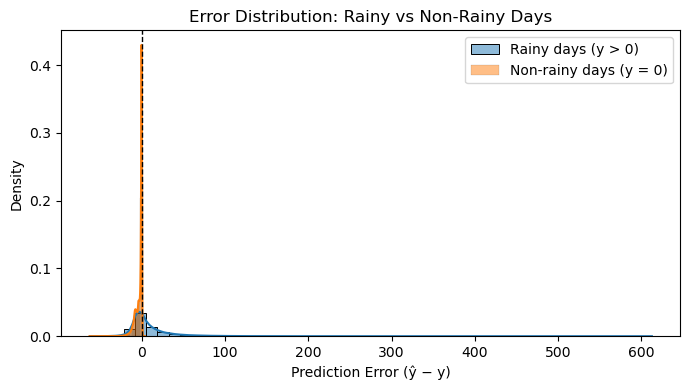

In [149]:
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:blue",
    label="Rainy days (y > 0)",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_rainy_mask, "error"],
    bins=50,
    kde=True,
    color="tab:orange",
    label="Non-rainy days (y = 0)",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Rainy vs Non-Rainy Days")
plt.legend()
plt.tight_layout()
plt.show()


In [153]:
df_eval["pred_rain"] = df_eval["yhat"] > 0
df_eval["true_rain"] = df_eval["y"] > 0

pd.crosstab(
    df_eval["true_rain"],
    df_eval["pred_rain"],
    normalize="index"
)


pred_rain,False,True
true_rain,,
False,0.100462,0.899538
True,0.004032,0.995968


### conditional rmse

In [157]:
def conditional_rmse(mask, name):
    e = df_eval.loc[mask]
    return {
        "Regime": name,
        "RMSE": rmse(e.y, e.yhat),
        "MAE": mae(e.y, e.yhat),
        "Bias": bias(e.y, e.yhat),
        "Count": len(e)
    }

pd.DataFrame([
    conditional_rmse(df_eval.y == 0, "Non-rainy"),
    conditional_rmse((df_eval.y > 0) & (df_eval.y <= 10), "Light rain"),
    conditional_rmse((df_eval.y > 10) & (df_eval.y <= 50), "Moderate rain"),
    conditional_rmse(df_eval.y > 50, "Heavy rain"),
])


,Regime,RMSE,MAE,Bias,Count
0,Non-rainy,5.474777,3.180259,3.161169,418964
1,Light rain,8.919576,6.608468,5.529953,83490
2,Moderate rain,17.130159,13.695995,-11.697448,67003
3,Heavy rain,82.355698,70.138367,-70.124535,15945


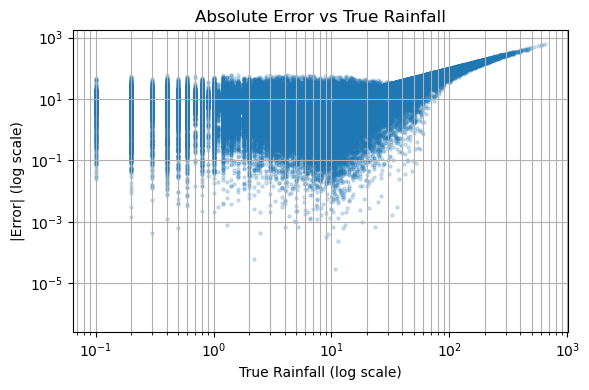

In [159]:
plt.figure(figsize=(6, 4))

plt.scatter(
    df_eval["y"],
    np.abs(df_eval["error"]),
    alpha=0.2,
    s=5
)

plt.xscale("log")
plt.yscale("log")
plt.xlabel("True Rainfall (log scale)")
plt.ylabel("|Error| (log scale)")
plt.title("Absolute Error vs True Rainfall")
plt.grid(True, which="both")
plt.tight_layout()
plt.show()


#### Monsoon vs non-monsoon

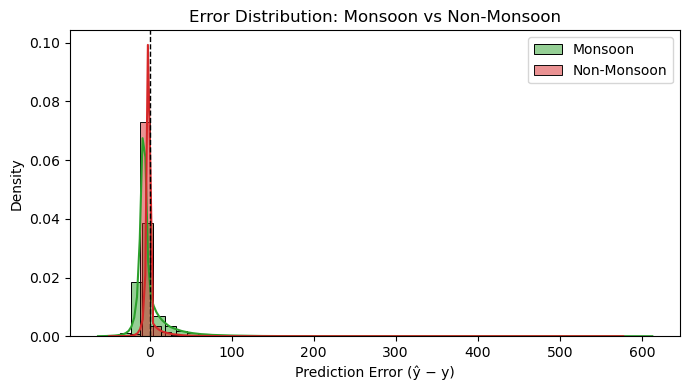

In [162]:
plt.figure(figsize=(7, 4))

sns.histplot(
    df_eval.loc[monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:green",
    label="Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_monsoon_mask, "error"],
    bins=50,
    kde=True,
    color="tab:red",
    label="Non-Monsoon",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution: Monsoon vs Non-Monsoon")
plt.legend()
plt.tight_layout()
plt.show()


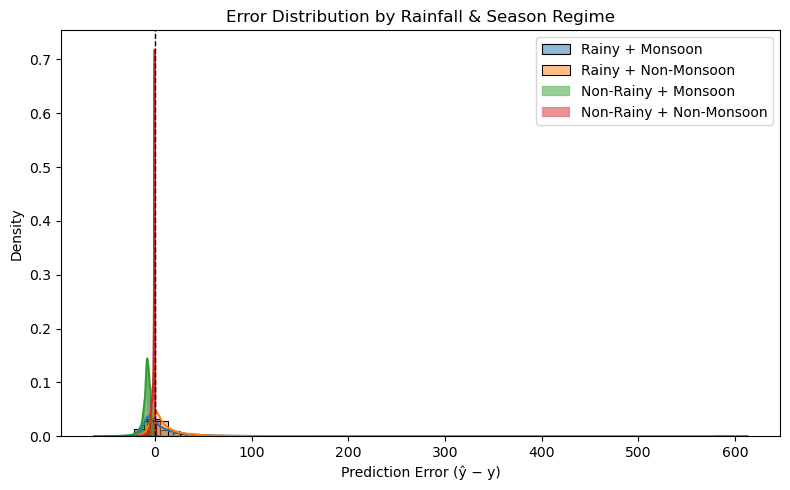

In [164]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_eval.loc[rainy_mask & monsoon_mask, "error"],
    bins=50,
    kde=True,
    label="Rainy + Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[rainy_mask & non_monsoon_mask, "error"],
    bins=50,
    kde=True,
    label="Rainy + Non-Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_rainy_mask & monsoon_mask, "error"],
    bins=50,
    kde=True,
    label="Non-Rainy + Monsoon",
    stat="density",
)

sns.histplot(
    df_eval.loc[non_rainy_mask & non_monsoon_mask, "error"],
    bins=50,
    kde=True,
    label="Non-Rainy + Non-Monsoon",
    stat="density",
)

plt.axvline(0, color="black", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution by Rainfall & Season Regime")
plt.legend()
plt.tight_layout()
plt.show()


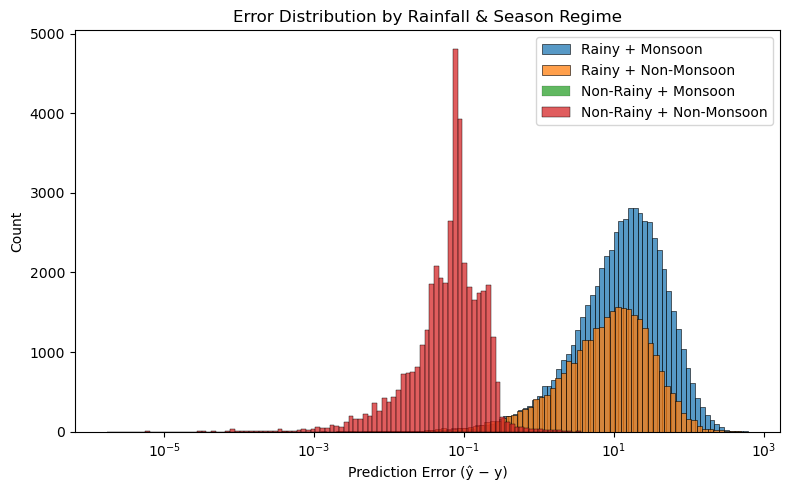

In [192]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df_eval.loc[rainy_mask & monsoon_mask, "error"] +1e-6,
    bins=100,
    log_scale=True,
    label="Rainy + Monsoon"
)

sns.histplot(
    df_eval.loc[rainy_mask & non_monsoon_mask, "error"] +1e-6,
    bins=100,
    log_scale=True,
    label="Rainy + Non-Monsoon"
)

sns.histplot(
    df_eval.loc[non_rainy_mask & monsoon_mask, "error"] +1e-6,
    bins=100,
    log_scale=True,
    label="Non-Rainy + Monsoon"
)

sns.histplot(
    df_eval.loc[non_rainy_mask & non_monsoon_mask, "error"] +1e-6,
    bins=100,
    log_scale=True,
    label="Non-Rainy + Non-Monsoon"
)

plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution by Rainfall & Season Regime")
plt.legend()
plt.tight_layout()
plt.show()


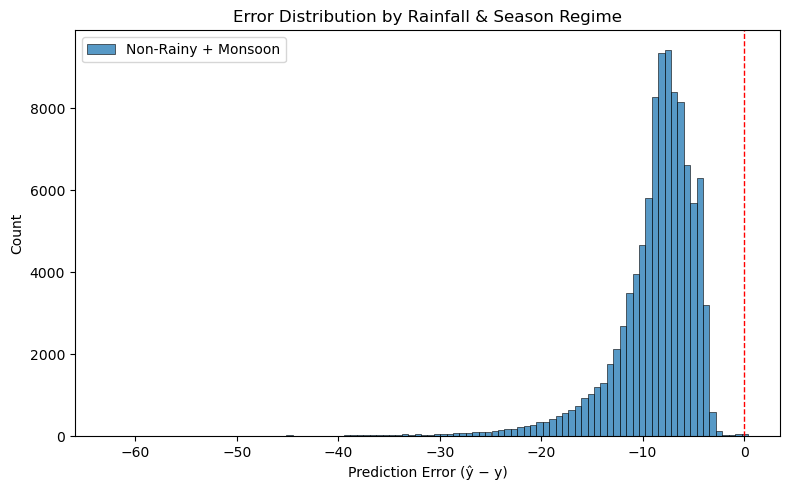

In [188]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df_eval.loc[non_rainy_mask & monsoon_mask, "error"] +1e-6,
    bins=100,
    # log_scale = True,
    label="Non-Rainy + Monsoon"
)

plt.axvline(0, color="red", linestyle="--", linewidth=1)
plt.xlabel("Prediction Error (ŷ − y)")
plt.title("Error Distribution by Rainfall & Season Regime")
plt.legend()
plt.tight_layout()
plt.show()

### Summary table

In [194]:
rows = []

def add_row(name, mask):
    e = df_eval.loc[mask, "error"]
    rows.append({
        "Regime": name,
        "Bias": np.mean(e),
        "MAE": np.mean(np.abs(e)),
        "RMSE": np.sqrt(np.mean(e**2)),
        "Samples": len(e)
    })

add_row("Rainy + Monsoon", rainy_mask & monsoon_mask)
add_row("Rainy + Non-Monsoon", rainy_mask & non_monsoon_mask)
add_row("Non-Rainy + Monsoon", non_rainy_mask & monsoon_mask)
add_row("Non-Rainy + Non-Monsoon", non_rainy_mask & non_monsoon_mask)

df_error_regimes = pd.DataFrame(rows)
df_error_regimes


,Regime,Bias,MAE,RMSE,Samples
0,Rainy + Monsoon,8.145941,16.513309,29.796783,123036
1,Rainy + Non-Monsoon,10.090781,12.811357,24.102203,43402
2,Non-Rainy + Monsoon,-8.943016,8.943066,10.113179,101542
3,Non-Rainy + Non-Monsoon,-1.311580,1.336761,2.616045,317422
